<a href="https://colab.research.google.com/github/Ibreez16/pandas_learning/blob/main/Pandas_Practice_(5_5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [ ]:
# import like this
items_path = "/content/drive/MyDrive/DSMP/01 - Python/Daily Tasks/Week 7/data/items.csv"
q1_path = "/content/drive/MyDrive/DSMP/01 - Python/Daily Tasks/Week 7/data/quarter-1.csv"
q2_path = "/content/drive/MyDrive/DSMP/01 - Python/Daily Tasks/Week 7/data/quarter-2.csv"
q3_path = "/content/drive/MyDrive/DSMP/01 - Python/Daily Tasks/Week 7/data/quarter-3.csv"


q1= pd.read_csv('/content/quarter-1.csv')
q2 = pd.read_csv('/content/quarter-2.csv')
q3 = pd.read_csv('/content/quarter-3.csv')

items = pd.read_csv('/content/items (1).csv')

###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [ ]:
# code here
quarter = pd.concat([q1, q2, q3], keys=['Q1', 'Q2', 'Q3']).reset_index()

In [ ]:
quarter

,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price
0,Q1,0,1,1,1,1,$3.39
1,Q1,1,1,1,2,2,$3.39
2,Q1,2,2,2,4,3,$16.98
3,Q1,3,4,1,7,6,$9.25
4,Q1,4,6,1,9,8,$8.75
...,...,...,...,...,...,...,...
4617,Q2,2342,1829,1,23,92,$11.25
4618,Q2,2343,1830,1,23,1043,$11.25
4619,Q2,2344,1832,1,10,116,$8.75
4620,Q2,2345,1832,1,8,0,$4.45


In [ ]:
items

,item_id,item_name
0,0,Chips and Fresh Tomato Salsa
1,1,Izze
2,2,Nantucket Nectar
3,3,Chips and Tomatillo-Green Chili Salsa
4,4,Chicken Bowl
5,5,Side of Chips
6,6,Steak Burrito
7,7,Steak Soft Tacos
8,8,Chips and Guacamole
9,9,Chicken Crispy Tacos


In [ ]:
items.merge(quarter, on='item_id')

,item_id,item_name,level_0,level_1,order_id,quantity,choice_description_id,item_price
0,0,Chips and Fresh Tomato Salsa,Q1,11,13,1,0,$2.39
1,0,Chips and Fresh Tomato Salsa,Q1,92,82,1,0,$2.95
2,0,Chips and Fresh Tomato Salsa,Q1,120,104,1,0,$2.95
3,0,Chips and Fresh Tomato Salsa,Q1,163,142,1,0,$2.39
4,0,Chips and Fresh Tomato Salsa,Q1,168,149,1,0,$2.95
...,...,...,...,...,...,...,...,...
4617,48,Veggie Salad,Q2,1411,1094,1,755,$8.49
4618,48,Veggie Salad,Q2,1528,1192,1,149,$8.49
4619,48,Veggie Salad,Q2,1605,1263,1,306,$8.49
4620,48,Veggie Salad,Q2,1745,1395,1,755,$8.49


In [ ]:
items.merge(quarter, on='item_id').groupby("level_0")["item_name"].value_counts().reset_index().sort_values(by="count", ascending=False).drop_duplicates('level_0').sort_index()

,level_0,item_name,count
0,Q1,Chicken Bowl,351
49,Q2,Chicken Bowl,375


###`Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [1]:
# code here
import numpy as np
import pandas as pd
del_df = pd.read_csv("/content/deliveries1.csv")
match_df = pd.read_csv("/content/matches.csv")

In [ ]:
del_df

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,1.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,2.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,3.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,4.0,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,4.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,5.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,2.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112640,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,3.0,GJ Bailey,R Dhawan,MA Starc,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
112641,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,4.0,GJ Bailey,R Dhawan,MA Starc,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,NaN,NaN,NaN
112642,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,5.0,R Dhawan,GJ Bailey,MA Starc,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
112643,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,6.0,R Dhawan,GJ Bailey,MA Starc,0.0,...,0.0,0.0,0.0,0.0,2.0,0.0,2.0,NaN,NaN,NaN


In [ ]:
match_df

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631,632,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,2016-05-27,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN


In [ ]:
temp_df = del_df.merge(match_df, left_on="match_id", right_on="id")
temp_df

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,1.0,DA Warner,S Dhawan,TS Mills,0.0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,2.0,DA Warner,S Dhawan,TS Mills,0.0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,3.0,DA Warner,S Dhawan,TS Mills,0.0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,4.0,DA Warner,S Dhawan,TS Mills,0.0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,5.0,DA Warner,S Dhawan,TS Mills,0.0,...,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112640,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,3.0,GJ Bailey,R Dhawan,MA Starc,0.0,...,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi,NaN
112641,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,4.0,GJ Bailey,R Dhawan,MA Starc,0.0,...,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi,NaN
112642,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,5.0,R Dhawan,GJ Bailey,MA Starc,0.0,...,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi,NaN
112643,475,2,Kings XI Punjab,Royal Challengers Bangalore,16.0,6.0,R Dhawan,GJ Bailey,MA Starc,0.0,...,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi,NaN


In [ ]:
temp_df.groupby(['season', "bowler"])[['player_dismissed','total_runs']].agg({
    'player_dismissed':'count',
    'total_runs':'sum'
}).sort_values(["player_dismissed", 'total_runs'],ascending=[False, True]).reset_index().drop_duplicates('season').sort_values("season")

,season,bowler,player_dismissed,total_runs
12,2008,Sohail Tanvir,24,275.0
9,2009,RP Singh,26,430.0
21,2010,PP Ojha,22,439.0
2,2011,SL Malinga,30,393.0
3,2012,M Morkel,30,466.0
0,2013,DJ Bravo,34,505.0
227,2014,SP Narine,9,87.0
5,2017,B Kumar,28,384.0


###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [ ]:
# code here
temp_df.groupby(["over", 'bowler'])['player_dismissed'].count().loc[16:20]

over  bowler        
16.0  A Ashish Reddy     2
      A Flintoff         0
      A Kumble           3
      A Mishra          11
      A Nehra            9
                        ..
20.0  WD Parnell         8
      WPUJC Vaas         3
      YA Abdulla         2
      YK Pathan          1
      Z Khan             7
Name: player_dismissed, Length: 943, dtype: int64

In [ ]:
temp_df[temp_df['over'] > 15].groupby(['bowler'])[['player_dismissed', 'total_runs']].agg({
    'player_dismissed':'count',
    'total_runs':'sum'
}).sort_values("player_dismissed", ascending=False).head(1)

,player_dismissed,total_runs
bowler,,
SL Malinga,82,987.0


###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [ ]:
# code here


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [ ]:
# code here

## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [2]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")


In [7]:
setosa

,Unnamed: 0,Id,Species
0,0,1,Iris-setosa
1,1,2,Iris-setosa
2,2,3,Iris-setosa
3,3,4,Iris-setosa
4,4,5,Iris-setosa
5,5,6,Iris-setosa
6,6,7,Iris-setosa
7,7,8,Iris-setosa
8,8,9,Iris-setosa
9,9,10,Iris-setosa


In [6]:
versicolor

,Unnamed: 0,Id,Species
0,50,51,Iris-versicolor
1,51,52,Iris-versicolor
2,52,53,Iris-versicolor
3,53,54,Iris-versicolor
4,54,55,Iris-versicolor
5,55,56,Iris-versicolor
6,56,57,Iris-versicolor
7,57,58,Iris-versicolor
8,58,59,Iris-versicolor
9,59,60,Iris-versicolor


In [4]:
petal_all

,Unnamed: 0,Id,PetalLengthCm,PetalWidthCm
0,0,1,1.4,0.2
1,1,2,1.4,0.2
2,2,3,1.3,0.2
3,3,4,1.5,0.2
4,4,5,1.4,0.2
...,...,...,...,...
145,145,146,5.2,2.3
146,146,147,5.0,1.9
147,147,148,5.2,2.0
148,148,149,5.4,2.3


In [3]:
sepal_all

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm
0,0,1,5.1,3.5
1,1,2,4.9,3.0
2,2,3,4.7,3.2
3,3,4,4.6,3.1
4,4,5,5.0,3.6
...,...,...,...,...
145,145,146,6.7,3.0
146,146,147,6.3,2.5
147,147,148,6.5,3.0
148,148,149,6.2,3.4


In [5]:
virginica

,Unnamed: 0,Id,Species
0,100,101,Iris-virginica
1,101,102,Iris-virginica
2,102,103,Iris-virginica
3,103,104,Iris-virginica
4,104,105,Iris-virginica
5,105,106,Iris-virginica
6,106,107,Iris-virginica
7,107,108,Iris-virginica
8,108,109,Iris-virginica
9,109,110,Iris-virginica


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

<Axes: >

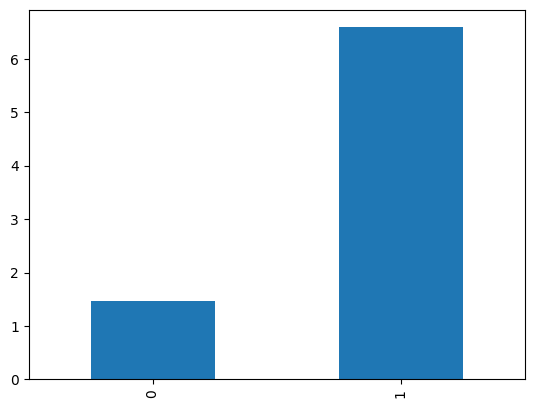

In [15]:
# code here
avg_sepal_virginica = sepal_all.merge(virginica, how='right',on='Id')['SepalLengthCm'].mean()
avg_sepal_virginica

avg_petal_setosa = petal_all.merge(setosa, how='right',on='Id')['PetalLengthCm'].mean()
avg_petal_setosa

pd.Series([avg_petal_setosa, avg_sepal_virginica]).plot(kind='bar')

### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [30]:
# code here
temp_df = sepal_all.merge(petal_all, on='Id')
stacked_df = pd.concat([setosa,versicolor,virginica])
final_df = temp_df.merge(stacked_df, on='Id')

final_df = final_df.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y', 'Unnamed: 0'])
final_df = final_df[[
    'Id',
    'Species',
    'SepalLengthCm',
    'SepalWidthCm',
    'PetalLengthCm',
    'PetalWidthCm'
]]

final_df.sample(frac=1)

,Id,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
35,36,Iris-setosa,5.0,3.2,1.2,0.2
124,125,Iris-virginica,6.7,3.3,5.7,2.1
125,126,Iris-virginica,7.2,3.2,6.0,1.8
114,115,Iris-virginica,5.8,2.8,5.1,2.4
98,99,Iris-versicolor,5.1,2.5,3.0,1.1
...,...,...,...,...,...,...
16,17,Iris-setosa,5.4,3.9,1.3,0.4
59,60,Iris-versicolor,5.2,2.7,3.9,1.4
134,135,Iris-virginica,6.1,2.6,5.6,1.4
146,147,Iris-virginica,6.3,2.5,5.0,1.9


### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [42]:
setosa_versicolor = pd.concat([setosa, versicolor])
df = temp_df.merge(setosa_versicolor, on="Id")
df = df.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y', 'Unnamed: 0'])
result = df.groupby('Species').agg({
    'SepalWidthCm': ['min', 'max'],
    'PetalWidthCm' : ['min', 'max']
})


SepalWidthCm      PetalWidthCm     
                         min  max          min  max
Species                                            
Iris-setosa              2.3  4.4          0.1  0.6
Iris-versicolor          2.0  3.4          1.0  1.8

In [ ]:
# code here